<a href="https://colab.research.google.com/github/Nightfury2062/frootify/blob/main/Frootify_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# basic data regarding dataset


import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/frootify/Dataset.csv")

print(df.shape)

print(df.info())

print(df.head())

print(df.describe())

(8115, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8115 entries, 0 to 8114
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Fruit        8115 non-null   object 
 1   Temp         8115 non-null   int64  
 2   Humid (%)    8115 non-null   int64  
 3   Light (Fux)  8115 non-null   float64
 4   CO2 (ppm)    8115 non-null   int64  
 5   Class        8115 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 380.5+ KB
None
       Fruit  Temp  Humid (%)  Light (Fux)  CO2 (ppm) Class
0     Orange    22         95     7.358649        361  Good
1     Orange    24         95    14.835898        370   Bad
2  Pineapple    25         95    10.104045        355   Bad
3     Banana    25         89    20.179643        388  Good
4     Tomato    23         90    12.621448        316  Good
              Temp    Humid (%)  Light (Fux)    CO2 (ppm)
count  8115.000000  8115.000000  8115.000000  8115.000000
mea

array([[<Axes: title={'center': 'Temp'}>,
        <Axes: title={'center': 'Humid (%)'}>],
       [<Axes: title={'center': 'Light (Fux)'}>,
        <Axes: title={'center': 'CO2 (ppm)'}>]], dtype=object)

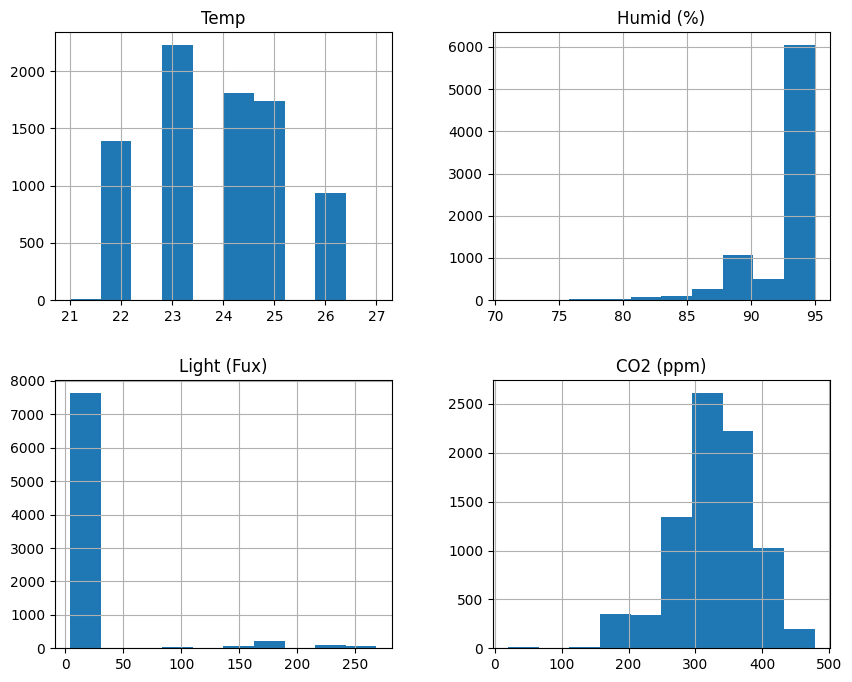

In [ ]:
numerical_cols=[
'Temp',
'Humid (%)',
'Light (Fux)',
'CO2 (ppm)'
]

df[numerical_cols].hist(
figsize=(10,8)
)

In [ ]:
# # Investigating high skew in Light


# print(df['Light (Fux)'].skew())

In [ ]:
# # using log transformation to remove skew


# import numpy as np

# df['Light (Fux)']=np.log1p(
# df['Light (Fux)']
# )
# print(
# df['Light (Fux)'].skew()
# )

In [ ]:


# import matplotlib.pyplot as plt

# plt.figure()

# df['Light (Fux)'].hist()

# plt.title("Original")

# plt.show()


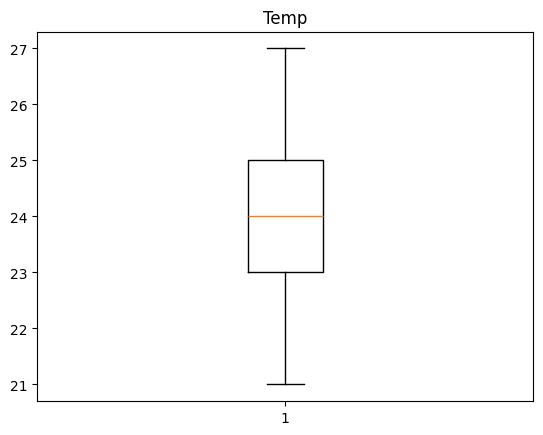

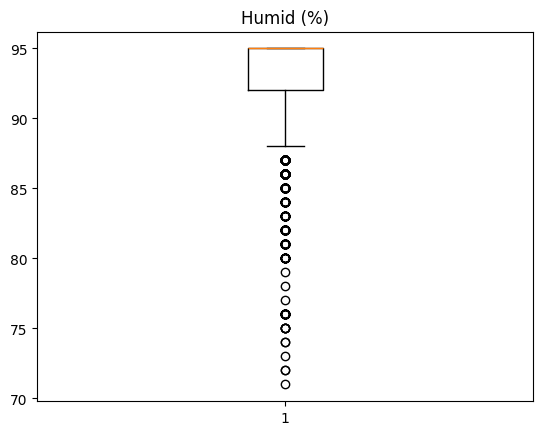

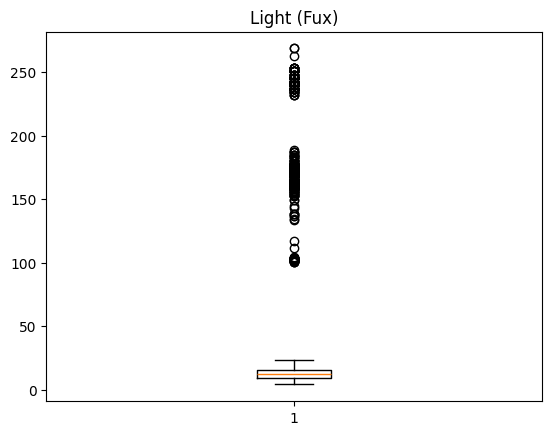

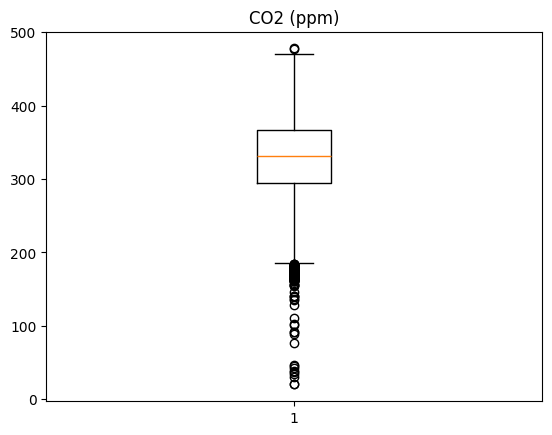

In [ ]:
# now using light_log with reduced skewness

import matplotlib.pyplot as plt

numerical_cols=[

'Temp',

'Humid (%)',

'Light (Fux)',

'CO2 (ppm)'

]

for col in numerical_cols:

    plt.figure()

    plt.boxplot(
        df[col]
    )

    plt.title(col)

    plt.show()

In [ ]:
corr=df[numerical_cols].corr()

print(corr)

                 Temp  Humid (%)  Light (Fux)  CO2 (ppm)
Temp         1.000000  -0.047897     0.367540   0.203242
Humid (%)   -0.047897   1.000000     0.122026  -0.178360
Light (Fux)  0.367540   0.122026     1.000000  -0.095733
CO2 (ppm)    0.203242  -0.178360    -0.095733   1.000000


EDA Conclusion

• Removed duplicate records and corrected class label inconsistencies to obtain a clean dataset.

• Dataset contains balanced class distribution with no significant class imbalance.

• Temperature values showed relatively normal distribution with no major abnormalities.

• Humidity values were concentrated in higher ranges, indicating high-humidity storage conditions.

• Light intensity showed high skewness; logarithmic transformation was applied to improve distribution.

• CO2 values showed reasonable variation with some extreme observations.

• Outlier analysis revealed that most outliers represent realistic environmental variations and were retained.

• Correlation analysis showed mostly weak relationships between variables, indicating low feature redundancy.

• Temperature and Light showed moderate positive correlation, while other features were weakly correlated.

• Overall, the dataset is clean, informative, and suitable for machine learning model development.


Feature Engineering and Selection

In [ ]:
# Creating 3 new features - temp x humidity , co2 / temp , high humidity

df['Temp_Humidity']=(
df['Temp']*
df['Humid (%)']
)

df['CO2_Temp_Ratio']=(
df['CO2 (ppm)']/
df['Temp']
)

df['High_Humidity']=(
df['Humid (%)']>90
).astype(int)

In [ ]:
# model cannot understand fruit names so have to convert

df = pd.get_dummies(

df,

columns=['Fruit']
)

In [ ]:
if 'Light_log' in df.columns:

    df.drop(
        'Light_log',
        axis=1,
        inplace=True
    )

In [ ]:
print(
df.columns
)

Index(['Temp', 'Humid (%)', 'Light (Fux)', 'CO2 (ppm)', 'Class',
       'Temp_Humidity', 'CO2_Temp_Ratio', 'High_Humidity', 'Fruit_Banana',
       'Fruit_Orange', 'Fruit_Pineapple', 'Fruit_Tomato'],
      dtype='object')


In [ ]:
# X is everything the models sees (so dont need output(Class - so will drop it) ) and Y is what model predicts

X = df.drop(
'Class',
axis=1
)

y = df['Class']

In [ ]:
# use 80/20 % for training data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(

X,

y,

test_size=.2,

random_state=42

)

In [ ]:
# # train logistic regression for baseline

# from sklearn.linear_model import LogisticRegression

# lr=LogisticRegression()

# lr.fit(

# X_train,

# y_train

# )

got the error-
--

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(

--

Meaning - model could not fully train before it stopped
caused when features have highly varying scales

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(
#     X_train
# )

# X_test_scaled = scaler.transform(
#     X_test
# )

# # fit_transform()

# # ↓

# # learn scaling from training set


# # transform()

# # ↓

# # apply same scaling to test set

In [ ]:
# # now retrain (scaling done)

# from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression()

# lr.fit(

# X_train_scaled,

# y_train

# )

In [ ]:
# pred_lr = lr.predict(
#     X_test_scaled
# )

In [ ]:
# from sklearn.metrics import classification_report

# print(

# classification_report(

# y_test,

# pred_lr

# )

# )

How my logistic regression model performs-

Bad precision = 0.87 which means 87% of the time when model tells fruit is bad, it actually was bad
Same for good, in fact higher (94%)

recall is basically out of the actual bad ones, how many bad did the model detect, which was 93%, so in a real world scenario, only 7% of actual spoiled fruits will go undetected

and out of the actual good samples, 88% was detected, which is decent. For our use case, Bad recall matters more (in order to prevent spoilage)


F1 score - combines precision and recall into 1 metric
penalizes situations where data is unbalanced ( 1 metric higher than the other)



Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 42) #same as logistic model

rf.fit(

X_train,

y_train

)

RandomForestClassifier(random_state=42)

In [ ]:
pred_rf = rf.predict(

X_test  #not using X_test_scaled as scaling not reqd for random forest

)
#each tree votes good/bad based on individual computations

In [ ]:
from sklearn.metrics import classification_report

print(

classification_report(

y_test,

pred_rf,

digits = 5

)

)

              precision    recall  f1-score   support

         Bad    0.99861   0.99583   0.99721       719
        Good    0.99669   0.99889   0.99779       904

    accuracy                        0.99754      1623
   macro avg    0.99765   0.99736   0.99750      1623
weighted avg    0.99754   0.99754   0.99754      1623



In [ ]:
print(X.columns)

Index(['Temp', 'Humid (%)', 'Light (Fux)', 'CO2 (ppm)', 'Temp_Humidity',
       'CO2_Temp_Ratio', 'High_Humidity', 'Fruit_Banana', 'Fruit_Orange',
       'Fruit_Pineapple', 'Fruit_Tomato'],
      dtype='object')


'Class' not included in columns so target not leaked

In [ ]:
print(

X_train.shape,

X_test.shape

)
#check train vs test 80/20 split

(6492, 11) (1623, 11)


In [ ]:
from sklearn.metrics import confusion_matrix

print(

confusion_matrix(

y_test,

pred_rf

)

)

[[716   3]
 [  1 903]]


In [ ]:
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(

# rf,

# X,

# y,

# cv=5

# )

# print(scores)

# print(scores.mean())

NOT perfect score

717 + 902 = 1619

total tests = 1623

accuracy = 0.997535

classification report() prints upto 2 decimal places so 0.99 -> 1

Bad Recall  = 0.997218

Bad precision = 0.997218

Good Recall = 0.997787

In [ ]:
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(

# rf,

# X,

# y,

# cv=5,

# scoring='f1'

# )

# print(scores)

# print(scores.mean())

In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.metrics import make_scorer
# from sklearn.metrics import f1_score

# f1_bad = make_scorer(
#     f1_score,
#     pos_label='Bad'
# )
# # telling f1 to treat bad as positive label

# scores = cross_val_score(

#     rf,

#     X,

#     y,

#     cv=5,

#     scoring=f1_bad

# )
# # 5 fold cross validation testing

# print(scores)

# print(scores.mean())

last fold performs worse.

will try with higher folds (10) to see whether there is clustering or some other issue

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import f1_score

f1_bad = make_scorer(
    f1_score,
    pos_label='Bad'
)
# telling f1 to treat bad as positive label

scores = cross_val_score(

    rf,

    X,

    y,

    cv=10,

    scoring=f1_bad

)
# 10 fold cross validation testing

print(scores)

print(scores.mean())

[1.         0.9971831  0.99858956 0.9971831  0.99858956 1.
 0.99858557 0.99717514 0.99576869 0.98719772]
0.997027244913115


In [ ]:
from sklearn.metrics import recall_score

recall_bad = make_scorer(
    recall_score,
    pos_label='Bad'
)

scores = cross_val_score(

rf,

X,

y,

cv=10,

scoring=recall_bad

)

print(scores)

[1.         0.9971831  0.9971831  0.9971831  0.9971831  1.
 0.99717514 0.99717514 0.99717514 0.97746479]


MUCH  BETTER RESULT, even better after removing unnecessary light_log column and using that data in light(fux)

In [ ]:
rf.feature_importances_

array([0.11030177, 0.15584573, 0.25735166, 0.0567837 , 0.23908278,
       0.04827663, 0.04179284, 0.03257913, 0.01412945, 0.02072749,
       0.02312881])

| Feature                                | Importance |
| -------------------------------------- | ---------: |
| Temp                                   |     0.1103 |
| Humid (%)                              |     0.1558 |
| Light (Fux) *(log transformed values)* |     0.2574 |
| CO2 (ppm)                              |     0.0568 |
| Temp_Humidity                          |     0.2391 |
| CO2_Temp_Ratio                         |     0.0483 |
| High_Humidity                          |     0.0418 |
| Fruit_Banana                           |     0.0326 |
| Fruit_Orange                           |     0.0141 |
| Fruit_Pineapple                        |     0.0207 |
| Fruit_Tomato                           |     0.0231 |


Now, Feature Configuration to figure out which are the unnecessary features and does removing them improve or decrease performance of the model

Feature Config A - Remove Fruit_Banana , orange, pineapple and tomato

In [ ]:
# # create a temporary X without fruit columns

# X_no_fruit = X.drop(

# [
# 'Fruit_Banana',

# 'Fruit_Orange',

# 'Fruit_Pineapple',

# 'Fruit_Tomato'

# ],

# axis=1

# )

In [ ]:
# # use 80/20 % for training data (no fruit)

# from sklearn.model_selection import train_test_split

# X_train_nf,X_test_nf,y_train_nf,y_test_nf=\
# train_test_split(

# X_no_fruit,

# y,

# test_size=.2,

# random_state=42

# )

In [ ]:
# # train using same settings

# from sklearn.ensemble import RandomForestClassifier

# rf_nf = RandomForestClassifier(

# random_state=42

# )

# rf_nf.fit(

# X_train_nf,

# y_train_nf

# )

In [ ]:
# pred_nf = rf_nf.predict(

# X_test_nf

# )

In [ ]:
# from sklearn.metrics import classification_report

# print(

# classification_report(

# y_test_nf,

# pred_nf,

# digits=5

# )

# )

Removing fruit features caused a small decrease in performance, indicating that fruit type contributes useful information, although environmental factors remain the primary drivers of spoilage prediction.

In [ ]:
# scores = cross_val_score(

# rf_nf,

# X_no_fruit,

# y,

# cv=10,

# scoring=f1_bad

# )

# print(scores)

# print(scores.mean())

original mean was 0.997027244913115. Slightly worse perfomance as expected after results from classification report

*Hyperparameter Tuning*

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier

There are 2 search methods -
1) grid search which basically tries every combo of no. of trees with depth values. This is slow O(mxn)

2) Random search - this tries random combos using RandomizedSearchCV. Faster and accurate

In [ ]:
# creating parameter space

param_grid={

'n_estimators':[100,200,300],  #n_estimators controls the number of trees

'max_depth':[10,20,30,None],   #controls how deep trees grow

'min_samples_split':[2,5,10],  #controls the minimum number of samples required to split. Higher => Less complex trees

'min_samples_leaf':[1,2,4]    #controls minimum samples at leaf node

}

In [ ]:
rf=RandomForestClassifier(

random_state=42

)

In [ ]:
# create random search

random_search = RandomizedSearchCV(

estimator=rf,

param_distributions=param_grid,  #means use only param_grid hyperparameters

n_iter=20, #means try 20 random combinations

cv=10,    #evaluate each configuration using 10 fold split

scoring=f1_bad,

random_state=42,

n_jobs=-1  #means use all cpu cores

)

In [ ]:
random_search.fit(

X_train,

y_train

)

RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict', pos_label=Bad))

In [ ]:
# create final rf

best_rf = random_search.best_estimator_

In [ ]:
pred = best_rf.predict(
X_test
)

In [ ]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}


Above is the best configuration and the score it got is below

In [ ]:
print(random_search.best_score_)

0.998230698428441


In [ ]:
# comparing against current (99.67) , slightly better performance

In [ ]:
print(

classification_report(

y_test,

pred,

digits=5

)

)

              precision    recall  f1-score   support

         Bad    0.99861   0.99583   0.99721       719
        Good    0.99669   0.99889   0.99779       904

    accuracy                        0.99754      1623
   macro avg    0.99765   0.99736   0.99750      1623
weighted avg    0.99754   0.99754   0.99754      1623



| Metric           | Logistic Regression | Random Forest (Default) | Random Forest (Tuned Final) |
| ---------------- | ------------------: | ----------------------: | --------------------------: |
| Accuracy         |                ~90% |                  99.75% |                      99.75% |
| Precision (Bad)  |                 86% |                  99.86% |                      99.86% |
| Recall (Bad)     |                 93% |                  99.58% |                      99.58% |
| F1 Score (Bad)   |                 90% |                  99.72% |                      99.72% |
| Cross Validation |               Lower |                  Strong |                      Strong |
| Final Choice     |            Baseline |               Excellent |               Final Model ✅ |


Random Forest significantly outperformed Logistic Regression, demonstrating superior capability in learning nonlinear relationships within environmental storage data.

Feature engineering improved model performance, with environmental variables contributing more strongly than crop type features.

Hyperparameter tuning produced minor improvements, indicating that the baseline Random Forest configuration was already highly effective.

The final tuned Random Forest model achieved excellent spoilage prediction performance and was selected as the final Model 1 architecture.

In [ ]:
# import joblib

In [ ]:
# print(best_rf)

# print(best_rf.n_features_in_)

In [ ]:
# joblib.dump(

#     best_rf,

#     '/content/drive/MyDrive/frootify/fruit_spoilage_rf.pkl'

# )

In [ ]:
# feature_order = list(
#     X.columns
# )

# print(feature_order)

# joblib.dump(

#     feature_order,

#     '/content/drive/MyDrive/frootify/feature_order.pkl'

# )

In [ ]:
# loaded_model = joblib.load(

# '/content/drive/MyDrive/frootify/fruit_spoilage_rf.pkl'

# )

# print(
# loaded_model
# )

# print(
# loaded_model.n_features_in_
# )

In [ ]:
# loaded_feature_order = joblib.load(

# '/content/drive/MyDrive/frootify/feature_order.pkl'

# )

# print(
# loaded_feature_order
# )

In [ ]:
# ==========================
# STEP 1
# Create Tomato Dataset
# ==========================

df_tomato = df[
    df['Fruit_Tomato'] == 1
].copy()

print(
    "Tomato Rows:",
    len(df_tomato)
)


# ==========================
# STEP 2
# Create X and y
# ==========================

y_tomato = df_tomato[
    'Class'
]

X_tomato = df_tomato.drop(

    columns=[

        'Class'

    ]

)


# ==========================
# STEP 3
# Remove Unwanted Features
# ==========================

X_tomato = X_tomato.drop(

    columns=[

        'CO2 (ppm)',

        'Light (Fux)',

        'Light_log',

        'CO2_Temp_Ratio',

        'Fruit_Banana',

        'Fruit_Orange',

        'Fruit_Pineapple',

        'Fruit_Tomato'

    ],

    errors='ignore'

)


print()

print(
    "Remaining Features:"
)

print(
    X_tomato.columns
)


# ==========================
# STEP 4
# Split
# ==========================

from sklearn.model_selection import train_test_split

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(

    X_tomato,

    y_tomato,

    test_size=0.2,

    random_state=42

)


# ==========================
# STEP 5
# Train RF
# ==========================

from sklearn.ensemble import RandomForestClassifier

rf_tomato = RandomForestClassifier(

    random_state=42

)

rf_tomato.fit(

    X_train_t,

    y_train_t

)


# ==========================
# STEP 6
# Predict
# ==========================

pred_tomato = rf_tomato.predict(

    X_test_t

)


# ==========================
# STEP 7
# Evaluate
# ==========================

from sklearn.metrics import classification_report

print()

print(

    classification_report(

        y_test_t,

        pred_tomato,

        digits=5

    )

)

Tomato Rows: 2819

Remaining Features:
Index(['Temp', 'Humid (%)', 'Temp_Humidity', 'High_Humidity'], dtype='object')

              precision    recall  f1-score   support

         Bad    0.89773   0.98750   0.94048       240
        Good    0.99000   0.91667   0.95192       324

    accuracy                        0.94681       564
   macro avg    0.94386   0.95208   0.94620       564
weighted avg    0.95074   0.94681   0.94705       564



In [ ]:
from sklearn.metrics import make_scorer

from sklearn.metrics import precision_score


bad_precision = make_scorer(

    precision_score,

    pos_label='Bad'

)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier


param_grid={

'n_estimators':[100,200,300,500],


'max_depth':[10,20,30,40,None],


'min_samples_split':

[2,

5,

10,

20

],


'min_samples_leaf':

[

1,

2,

4,

8

]

}

In [ ]:
random_search = RandomizedSearchCV(

RandomForestClassifier(

random_state=42

),

param_distributions=param_grid,

n_iter=20,

cv=10,

scoring=bad_precision,

random_state=42,

n_jobs=-1

)

In [ ]:
random_search.fit(

X_train_t,

y_train_t

)

RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, None],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42,
                   scoring=make_scorer(precision_score, response_method='predict', pos_label=Bad))

In [ ]:
print(

random_search.best_params_

)

print(

random_search.best_score_

)

{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}
0.9092774494776432


In [ ]:
best_rf_tomato = random_search.best_estimator_

In [ ]:
pred_tuned = best_rf_tomato.predict(

X_test_t

)

In [ ]:
from sklearn.metrics import classification_report


print(

classification_report(

y_test_t,

pred_tuned,

digits=5

)

)

              precision    recall  f1-score   support

         Bad    0.89773   0.98750   0.94048       240
        Good    0.99000   0.91667   0.95192       324

    accuracy                        0.94681       564
   macro avg    0.94386   0.95208   0.94620       564
weighted avg    0.95074   0.94681   0.94705       564



In [ ]:
import joblib


joblib.dump(

best_rf_tomato,

'fruit_spoilage_rf_tomato.pkl'

)

['fruit_spoilage_rf_tomato.pkl']

In [ ]:
feature_order_tomato = list(

X_tomato.columns

)

print(

feature_order_tomato

)

['Temp', 'Humid (%)', 'Temp_Humidity', 'High_Humidity']


In [ ]:
joblib.dump(

feature_order_tomato,

'feature_order_tomato.pkl'

)

['feature_order_tomato.pkl']

In [ ]:
preprocessing={

'features_created':[

'Temp_Humidity',

'High_Humidity'

]

}

joblib.dump(

preprocessing,

'preprocessing_tomato.pkl'

)

['preprocessing_tomato.pkl']

In [ ]:
joblib.dump(

best_rf_tomato,

'/content/drive/MyDrive/frootify/fruit_spoilage_rf_tomato.pkl'

)

joblib.dump(

feature_order_tomato,

'/content/drive/MyDrive/frootify/feature_order_tomato.pkl'

)

joblib.dump(

preprocessing,

'/content/drive/MyDrive/frootify/preprocessing_tomato.pkl'

)

['/content/drive/MyDrive/frootify/preprocessing_tomato.pkl']